In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
df = pd.read_csv('/content/placementdata.csv')

In [51]:
le = LabelEncoder()
df['ExtracurricularActivities'] = le.fit_transform(df['ExtracurricularActivities'])
df['PlacementTraining'] = le.fit_transform(df['PlacementTraining'])


In [52]:
df['PlacementStatus'] = le.fit_transform(df['PlacementStatus'])

In [53]:
X = df.drop(columns=['PlacementStatus'])
y = df['PlacementStatus']


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
print("LOGISTIC REGRESSION")
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train) # Model ko train kiya
lr_predictions = lr_model.predict(X_test_scaled) # Prediction nikali

lr_acc = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(classification_report(y_test, lr_predictions))
print("-" * 50)

LOGISTIC REGRESSION
Logistic Regression Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

--------------------------------------------------


In [57]:
print("\nK-NEAREST NEIGHBORS (KNN)")
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train) # Model ko train kiya
knn_predictions = knn_model.predict(X_test_scaled) # Prediction nikali

knn_acc = accuracy_score(y_test, knn_predictions)
print(f"KNN Accuracy: {knn_acc:.4f}")
print(classification_report(y_test, knn_predictions))
print("-" * 50)



K-NEAREST NEIGHBORS (KNN)
KNN Accuracy: 0.7710
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1172
           1       0.73      0.71      0.72       828

    accuracy                           0.77      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000

--------------------------------------------------


In [58]:
print("\nDECISION TREE")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train) # Model ko train kiya
dt_predictions = dt_model.predict(X_test_scaled) # Prediction nikali

dt_acc = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(classification_report(y_test, dt_predictions))
print("-" * 50)


DECISION TREE
Decision Tree Accuracy: 0.7250
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      1172
           1       0.67      0.67      0.67       828

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.72      0.73      2000

--------------------------------------------------


In [59]:
print("\nRANDOM FOREST")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train) # Model ko train kiya
rf_predictions = rf_model.predict(X_test_scaled) # Prediction nikali

rf_acc = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_predictions))
print("-" * 50)



RANDOM FOREST
Random Forest Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1172
           1       0.76      0.73      0.75       828

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.79      2000
weighted avg       0.79      0.79      0.79      2000

--------------------------------------------------


/tmp/ipykernel_1246/1855507626.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


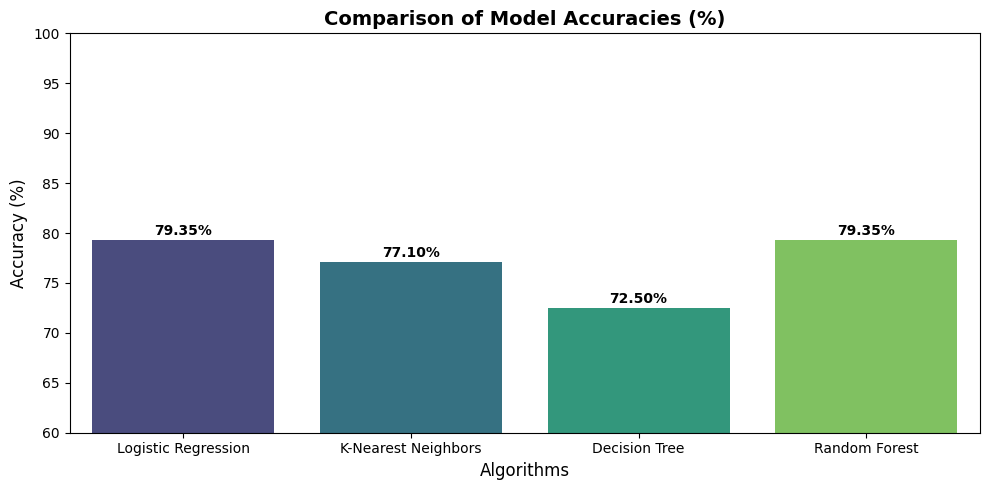

/tmp/ipykernel_1246/1855507626.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='mako')


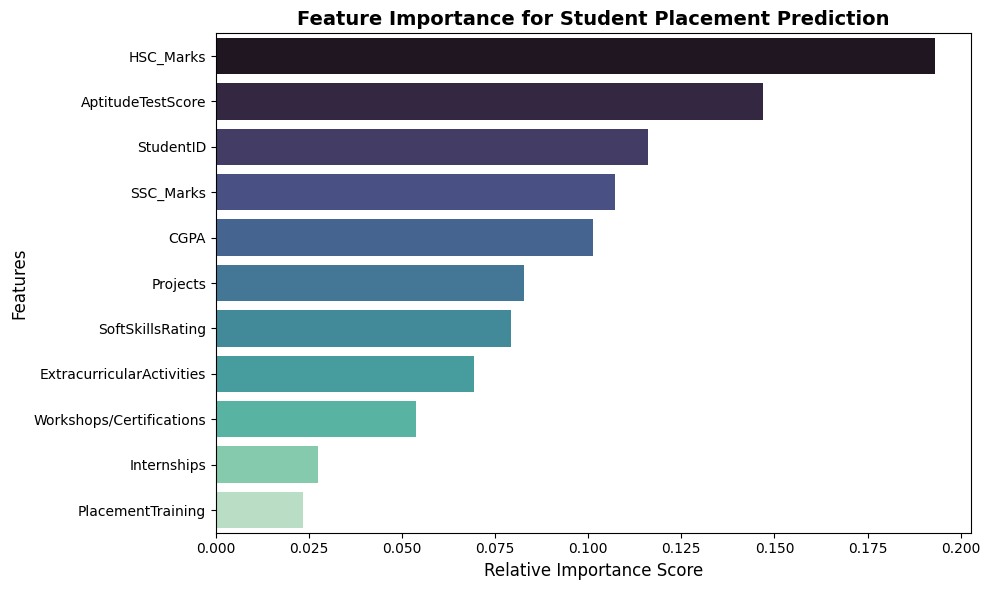

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc * 100, knn_acc * 100, dt_acc * 100, rf_acc * 100]

sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies (%)', fontsize=14, fontweight='bold')
plt.xlabel('Algorithms', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(60, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=feature_names[indices], palette='mako')
plt.title('Feature Importance for Student Placement Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

In [61]:
print("\n FINAL ACCURACY SUMMARY:")
print(f"1.Logistic Regression : {lr_acc*100:.2f}%")
print(f"2.Random Forest       : {rf_acc*100:.2f}%")
print(f"3.K-Nearest Neighbors : {knn_acc*100:.2f}%")
print(f"4.Decision Tree       : {dt_acc*100:.2f}%")


 FINAL ACCURACY SUMMARY:
1.Logistic Regression : 79.35%
2.Random Forest       : 79.35%
3.K-Nearest Neighbors : 77.10%
4.Decision Tree       : 72.50%
